# BO library comparison: gpmp-contrib vs BoTorch vs Optuna

Walkthrough of the `bo/` pipeline. GP hyperparameters are fit by plain maximum likelihood: beta (mean), sigma^2 (variance) and rho (lengthscale) are fit this way, nu (Matern smoothness) is fixed. File-by-file map: `README.md`.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))
sys.path.insert(0, str(Path.cwd().parent / "src"))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import utils
import gpmp_bo, botorch_bo, optuna_bo
import grid_ablation
import compare
from problem import HARTMANN4, HARTMANN6, ISHIGAMI

Path("results").mkdir(exist_ok=True)

## Functions

- `utils.py` -- acquisition math shared across backends, plus regret-band helpers.
- `gpmp_bo.py` / `botorch_bo.py` / `optuna_bo.py` -- one `run(acquisition, problem, seed, n_init, n_iter, direction) -> history` per library.
- `compare.py` -- runs all (library, acquisition) pairs on a problem, plots median regret.
- `grid_ablation.py` -- same idea, one acquisition (EI) x one problem, 3 candidate-search protocols x 3 libraries instead of 3 libraries x 4 acquisitions.

## Acquisition criteria

Posterior $\mathcal N(\mu(x), \sigma^2(x))$, incumbent $x^+$, $y^+ = $ best value observed.

$$\mathrm{EI}(x) = \mathbb E\big[\max(Y - y^+, 0)\big], \quad Y \sim \mathcal N(\mu(x), \sigma^2(x))$$
$$\mathrm{UCB}(x) = \mu(x) + \beta\,\sigma(x)$$
$$\mathrm{MaxVar}(x) = \sigma^2(x)$$
$$\mathrm{WeightedVar}(x) = w(x)\,\sigma^2(x), \qquad w(x) = \exp\!\Big(-\tfrac12 (x-x^+)^\top \Sigma^{-1} (x-x^+)\Big)$$

WeightedVar is Pi-BO-style (Hvarfner et al., 2022): a Gaussian prior weight on the incumbent, applied here to the variance criterion. $\Sigma$ isotropic, re-centered on $x^+$ every iteration.

## Candidate strategies compared by grid_ablation.py

The acquisition still has to be *optimized* over $x$ -- `grid_ablation.py` isolates this choice from the GP model, across all 3 libraries:

- **LHS, fixed grid** -- one static maximin-LHS candidate set (`gp.misc.designs.maximinlhs`), drawn once, argmax every iteration, never refined. Also what `compare.py` uses for all 3 libraries, so any gap there isolates the GP model, not the search.
- **Sobol, resampled** -- candidates redrawn every iteration from one persistent scrambled Sobol' sequence.
- **Gradient (BFGS)** -- each library's own continuous optimizer: BoTorch's `optimize_acqf`, Optuna's `optim_mixed.optimize_acqf_mixed`, and (gpmp-contrib has no native one) `gpmp_bo._gradient_argmax`, autodiff through gpmp's own `model.predict`.

## Reused from the underlying libraries

- gpmp / gpmp-contrib: `gp.misc.testfunctions.{hartmann4,hartmann6,ishigami}`, `gpmpcontrib.samplingcriteria.expected_improvement`, `gpmpcontrib.SequentialStrategyGridSearch`, `gpmpcontrib.Model_ConstantMean_Maternp_ML`, `gp.misc.designs.{ldrandunif,maximinlhs}`.
- BoTorch: `botorch.acquisition.analytic.{LogExpectedImprovement,UpperConfidenceBound}`, `botorch.optim.optimize_acqf`.
- Optuna: `optuna._gp` (private API, pinned version) -- the same GP-fitting/acquisition engine `optuna.samplers.GPSampler` itself calls.

New code, because no library ships it: `utils.max_variance`, `utils.gaussian_weight` / `weighted_variance` (WeightedVar), the UCB constant, and the plumbing that drives each library's own machinery through a common `run(...)` signature.

## 1. grid_ablation: quick live run (small budget, sanity check only)

In [ ]:
demo_results = grid_ablation.run_all(ISHIGAMI, n_repeats=2, n_init=6, n_iter=8, direction="min")
grid_ablation.plot(ISHIGAMI, demo_results, n_init=6, n_iter=8, direction="min", path="results/grid_ablation_demo.png")

### grid_ablation: full run

The curated `results/` folder at the repo root has a 100-repeat/40-iteration
example. To reproduce it: `python3 grid_ablation.py 100 40 20 Ishigami`
(writes to `results/grid/ml/ishigami_grid_ablation.png`).

In [ ]:
# see the markdown cell above -- no precomputed histories are bundled with this repo

## 2. compare: quick live run (Hartmann4, small budget, sanity check only)

  Hartmann4 EI           gpmp-contrib  5s
  Hartmann4 EI           BoTorch       2s
  Hartmann4 EI           Optuna        1s
  Hartmann4 MaxVar       gpmp-contrib  5s
  Hartmann4 MaxVar       BoTorch       1s
  Hartmann4 MaxVar       Optuna        0s
  Hartmann4 WeightedVar  gpmp-contrib  5s
  Hartmann4 WeightedVar  BoTorch       2s
  Hartmann4 WeightedVar  Optuna        0s
  Hartmann4 UCB          gpmp-contrib  5s
  Hartmann4 UCB          BoTorch       1s
  Hartmann4 UCB          Optuna        0s
saved results/hartmann4_demo.png


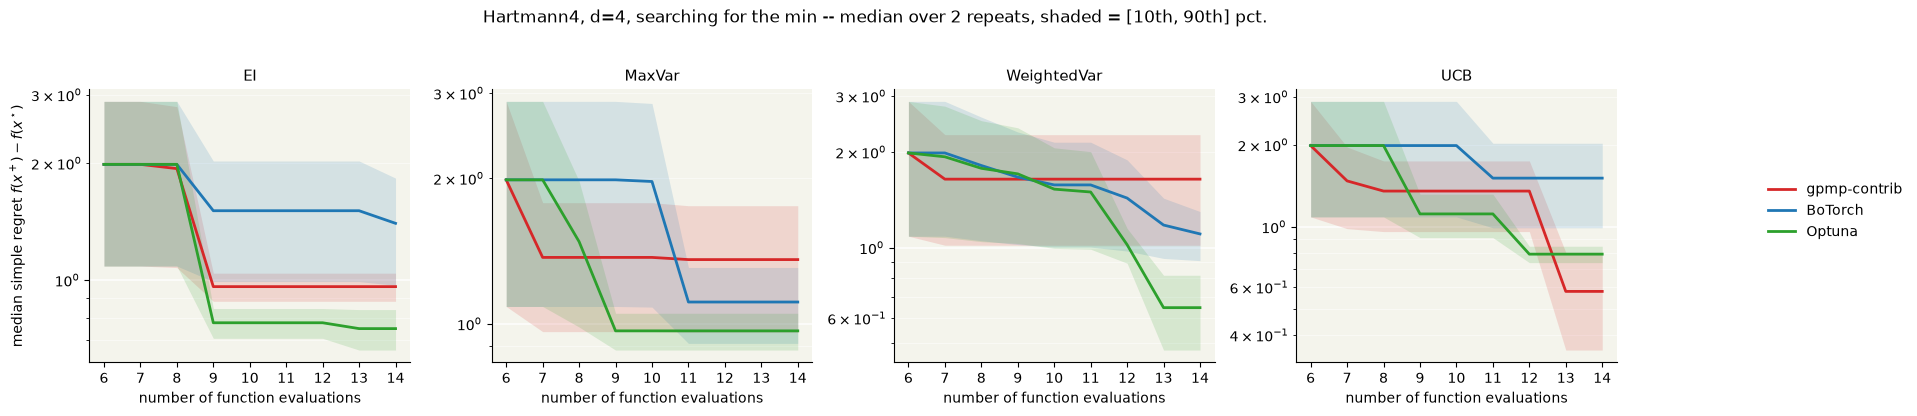

In [4]:
demo_results = compare.run_all(HARTMANN4, n_repeats=2, n_init=6, n_iter=8, direction="min")
compare.plot(HARTMANN4, demo_results, n_init=6, n_iter=8, direction="min", path="results/hartmann4_demo.png")

### compare: full run

Same story as above: the curated `results/` folder at the repo root has a
full-scale example. To reproduce it: `python3 compare.py 100 40 20 min`
(writes to `results/compare/`).

In [ ]:
# see the markdown cell above -- no precomputed histories are bundled with this repo